### Ejercicio - 1
Recorta el punto de interés de la **Image2.png** tal cual se muestra en la figura, guarda la imagen recortada en tu disco local, y muestra la imagen original y la recortada con axis (imagen a colores).

![Image2.png](Image2.png)

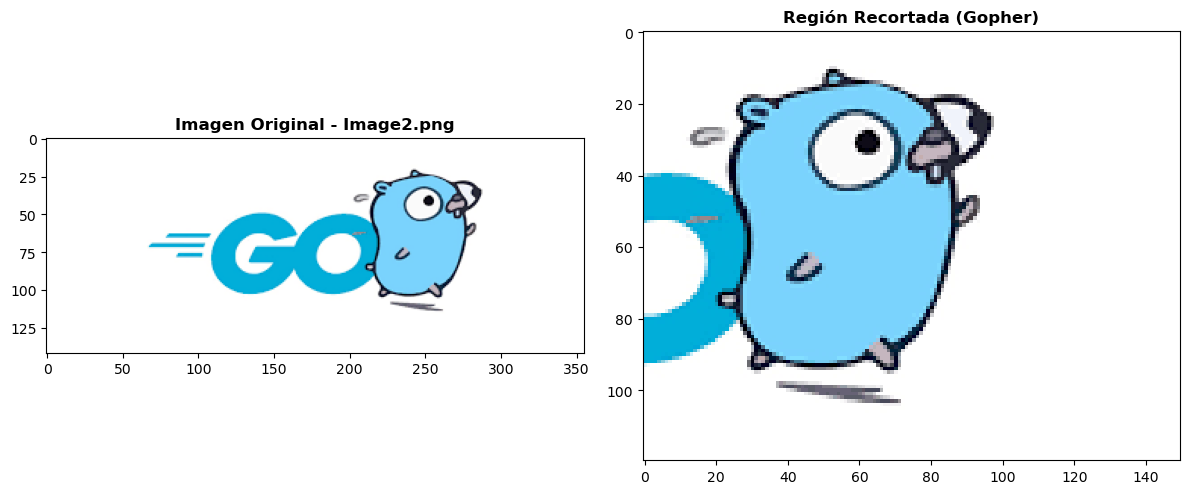

Imagen original: (142, 355, 3)
Imagen recortada: (120, 150, 3)
Imagen recortada guardada como 'Image2_recortada.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Cargar imagen original    
imagen = cv2.imread('Image2.png')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

# Definir región de interés (el gopher de Go)
# Coordenadas: y1:y2, x1:x2
roi = imagen_rgb[10:130, 190:340]

# Guardar imagen recortada
cv2.imwrite('Image2_recortada.png', cv2.cvtColor(roi, cv2.COLOR_RGB2BGR))

# Mostrar imagen original y recortada
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(imagen_rgb)
axes[0].set_title('Imagen Original - Image2.png', fontsize=12, fontweight='bold')

axes[1].imshow(roi)
axes[1].set_title('Región Recortada (Gopher)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Imagen original: {imagen.shape}")
print(f"Imagen recortada: {roi.shape}")
print("Imagen recortada guardada como 'Image2_recortada.png'")

### Me dio cosa hacer uso de la imagen original y recorte una que tenia a mano 

### Ejercicio - 2
Genera un degradado lineal a colores (debe coincidir con los mismos colores del espectro visible). De **rojo** desde abajo hasta llegar a **violeta** arriba. Se genera una imagen de 256x256 px con transición suave a través del espectro HSV.

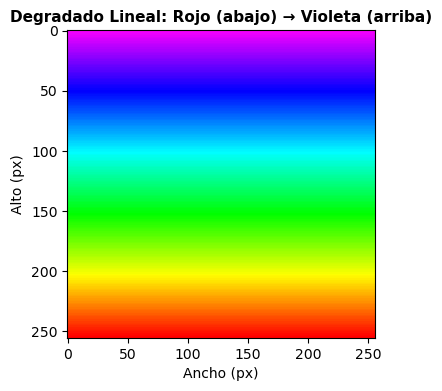

Imagen generada: (256, 256, 3)
Guardada como 'degradado_colores.png'


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
j
alto, ancho = 256, 256

# Crear imagen en espacio HSV
# H: 0 (rojo) abajo -> 150 (violeta) arriba en escala OpenCV (0-179)
# S y V a máximo para colores puros
hsv = np.zeros((alto, ancho, 3), dtype=np.uint8)

# Generar gradiente de Hue de abajo (rojo=0) a arriba (violeta=150)
for y in range(alto):
    # Fila 0 = arriba (violeta=150), fila 255 = abajo (rojo=0)
    hue = int(150 * (1 - y / (alto - 1)))
    hsv[y, :, 0] = hue       # Hue
    hsv[y, :, 1] = 255       # Saturación máxima
    hsv[y, :, 2] = 255       # Valor máximo

# Convertir HSV -> BGR -> RGB para visualización
degradado_bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
degradado_rgb = cv2.cvtColor(degradado_bgr, cv2.COLOR_BGR2RGB)

# Guardar imagen
cv2.imwrite('degradado_colores.png', degradado_bgr)

# Mostrar resultado
plt.figure(figsize=(4, 6))
plt.imshow(degradado_rgb)
plt.title('Degradado Lineal: Rojo (abajo) → Violeta (arriba)', fontsize=11, fontweight='bold')
plt.xlabel('Ancho (px)')
plt.ylabel('Alto (px)')
plt.tight_layout()
plt.show()

print(f"Imagen generada: {degradado_bgr.shape}")
print("Guardada como 'degradado_colores.png'")

### Ejercicio 3
Genera una imagen semejante a un **tablero de ajedrez** tomando en cuenta que cada casilla debe medir **100x100 px**. El tablero estándar es de 8x8 casillas (800x800 px total).

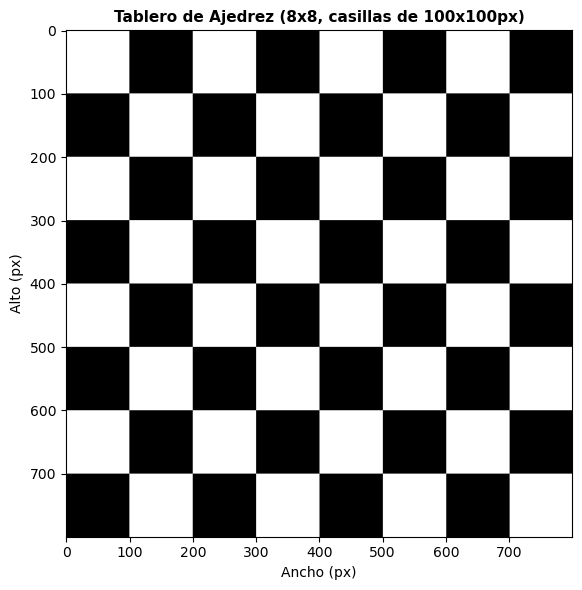

Tablero generado: (800, 800)
Guardado como 'tablero_ajedrez.png'


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

casilla = 100  # Tamaño de cada casilla en px
n_casillas = 8  # Tablero 8x8
tam = casilla * n_casillas  # 800x800 px

# Crear tablero usando operaciones vectorizadas
tablero = np.zeros((tam, tam), dtype=np.uint8)

for fila in range(n_casillas):
    for col in range(n_casillas):
        if (fila + col) % 2 == 0:
            y1, y2 = fila * casilla, (fila + 1) * casilla
            x1, x2 = col * casilla, (col + 1) * casilla
            tablero[y1:y2, x1:x2] = 255

# Guardar imagen
cv2.imwrite('tablero_ajedrez.png', tablero)

# Mostrar resultado
plt.figure(figsize=(6, 6))
plt.imshow(tablero, cmap='gray', vmin=0, vmax=255)
plt.title(f'Tablero de Ajedrez ({n_casillas}x{n_casillas}, casillas de {casilla}x{casilla}px)',
          fontsize=11, fontweight='bold')
plt.xlabel('Ancho (px)')
plt.ylabel('Alto (px)')
plt.tight_layout()
plt.show()

print(f"Tablero generado: {tablero.shape}")
print("Guardado como 'tablero_ajedrez.png'")

### Ejercicio - 4
Tomando en cuenta el resultado del **Ejercicio 2** (degradado de colores), aplica:
1. **Posterización** (reducción de niveles de color)
2. **Solarización** (inversión parcial de tonos)
3. Todas las **paletas de falso color** (colormaps) de OpenCV

Cada resultado debe guardarse en disco.

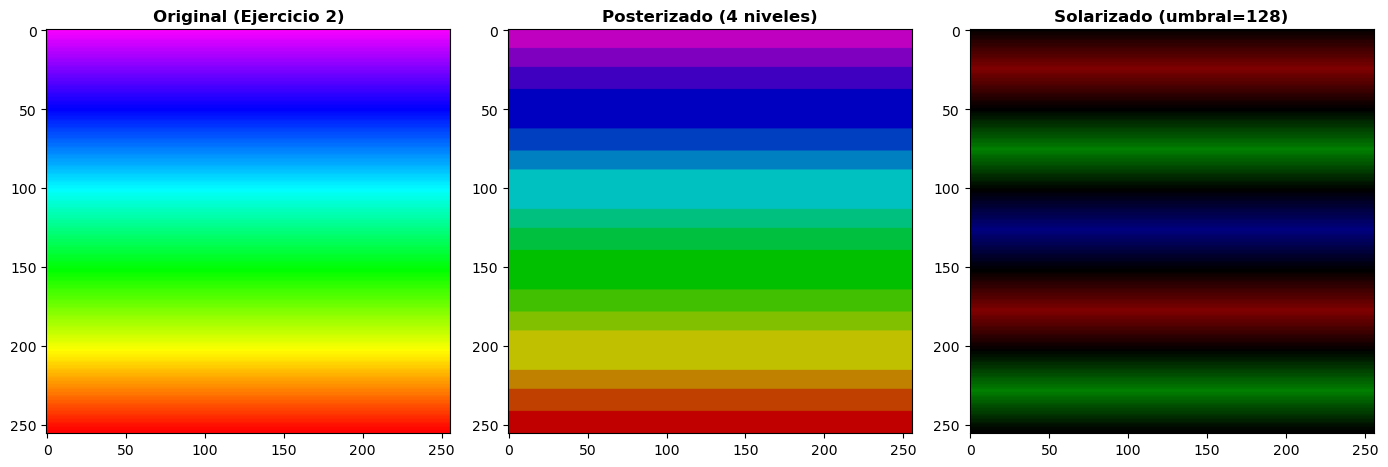

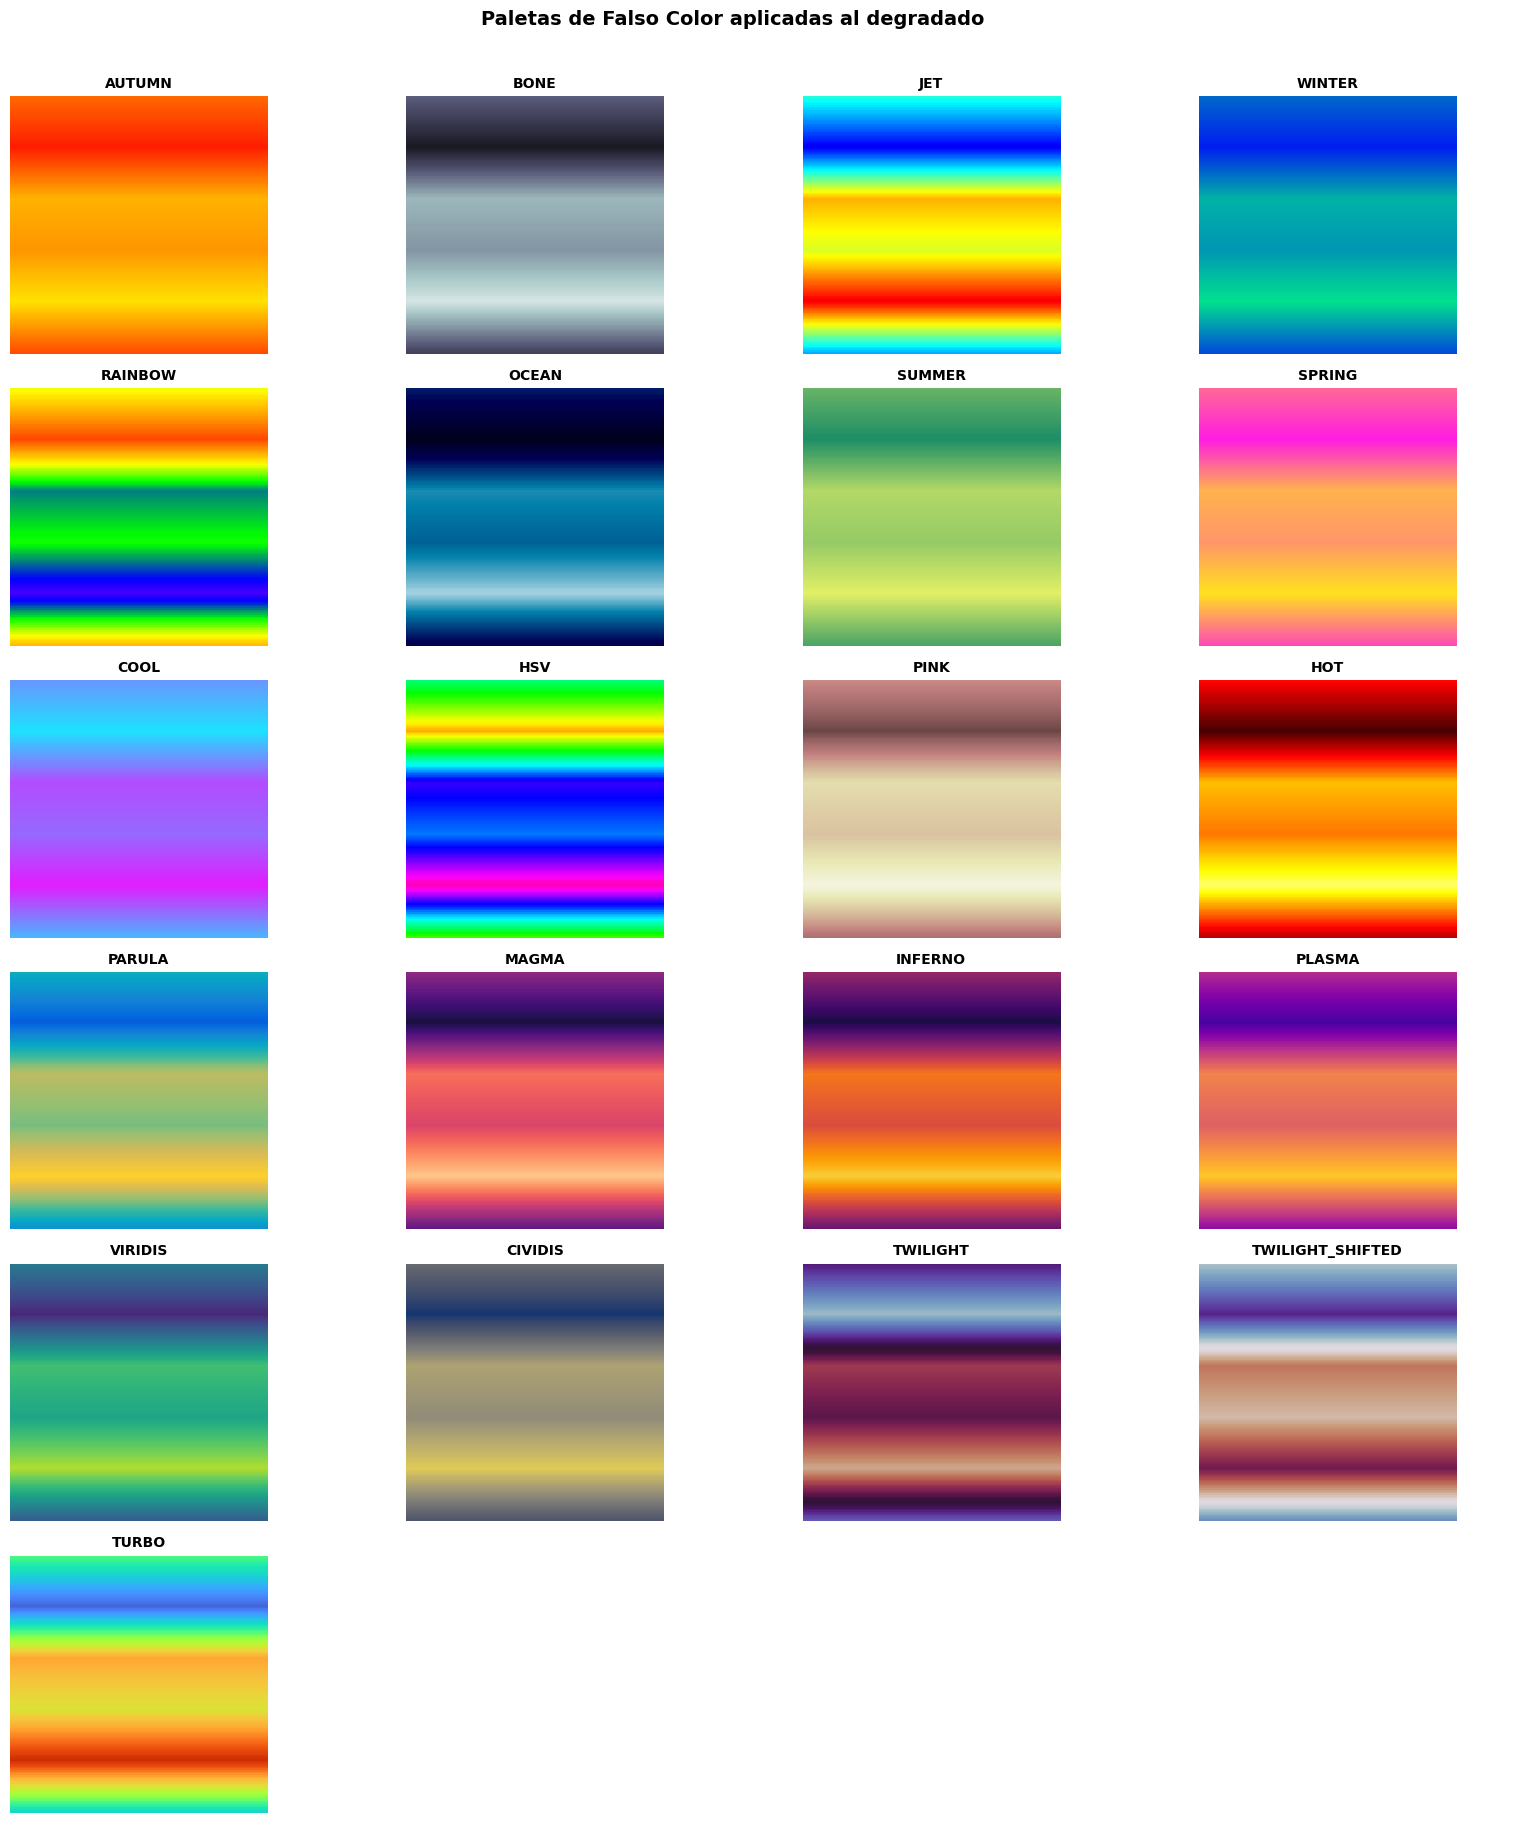

Total de imágenes guardadas: 23 (posterizado + solarizado + 21 paletas)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Cargar degradado del ejercicio 2
degradado = cv2.imread('degradado_colores.png')
degradado_rgb = cv2.cvtColor(degradado, cv2.COLOR_BGR2RGB)

# ========== 1. POSTERIZACIÓN ==========
# Reducir niveles de color (4 niveles por canal)
niveles = 4
factor = 256 // niveles
posterizado = (degradado // factor) * factor
posterizado_rgb = cv2.cvtColor(posterizado, cv2.COLOR_BGR2RGB)
cv2.imwrite('ej4_posterizado.png', posterizado)

# ========== 2. SOLARIZACIÓN ==========
# Invertir píxeles con valor > 128
umbral = 128
solarizado = degradado.copy()
solarizado[solarizado > umbral] = 255 - solarizado[solarizado > umbral]
solarizado_rgb = cv2.cvtColor(solarizado, cv2.COLOR_BGR2RGB)
cv2.imwrite('ej4_solarizado.png', solarizado)

# Mostrar posterización y solarización
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(degradado_rgb)
axes[0].set_title('Original (Ejercicio 2)', fontweight='bold')
axes[1].imshow(posterizado_rgb)
axes[1].set_title(f'Posterizado ({niveles} niveles)', fontweight='bold')
axes[2].imshow(solarizado_rgb)
axes[2].set_title(f'Solarizado (umbral={umbral})', fontweight='bold')
plt.tight_layout()
plt.show()

# ========== 3. PALETAS DE FALSO COLOR ==========
# Convertir a escala de grises para aplicar colormaps
degradado_gris = cv2.cvtColor(degradado, cv2.COLOR_BGR2GRAY)

# Todas las paletas de falso color de OpenCV
colormaps = {
    'AUTUMN': cv2.COLORMAP_AUTUMN,
    'BONE': cv2.COLORMAP_BONE,
    'JET': cv2.COLORMAP_JET,
    'WINTER': cv2.COLORMAP_WINTER,
    'RAINBOW': cv2.COLORMAP_RAINBOW,
    'OCEAN': cv2.COLORMAP_OCEAN,
    'SUMMER': cv2.COLORMAP_SUMMER,
    'SPRING': cv2.COLORMAP_SPRING,
    'COOL': cv2.COLORMAP_COOL,
    'HSV': cv2.COLORMAP_HSV,
    'PINK': cv2.COLORMAP_PINK,
    'HOT': cv2.COLORMAP_HOT,
    'PARULA': cv2.COLORMAP_PARULA,
    'MAGMA': cv2.COLORMAP_MAGMA,
    'INFERNO': cv2.COLORMAP_INFERNO,
    'PLASMA': cv2.COLORMAP_PLASMA,
    'VIRIDIS': cv2.COLORMAP_VIRIDIS,
    'CIVIDIS': cv2.COLORMAP_CIVIDIS,
    'TWILIGHT': cv2.COLORMAP_TWILIGHT,
    'TWILIGHT_SHIFTED': cv2.COLORMAP_TWILIGHT_SHIFTED,
    'TURBO': cv2.COLORMAP_TURBO,
}

n_maps = len(colormaps)
cols = 4
filas = (n_maps + cols - 1) // cols

fig, axes = plt.subplots(filas, cols, figsize=(16, filas * 3))
axes = axes.flatten()

for i, (nombre, cmap) in enumerate(colormaps.items()):
    falso_color = cv2.applyColorMap(degradado_gris, cmap)
    falso_color_rgb = cv2.cvtColor(falso_color, cv2.COLOR_BGR2RGB)
    
    # Guardar cada resultado
    cv2.imwrite(f'ej4_falsocolor_{nombre.lower()}.png', falso_color)
    
    axes[i].imshow(falso_color_rgb)
    axes[i].set_title(nombre, fontweight='bold', fontsize=10)
    axes[i].axis('off')

# Ocultar ejes vacíos
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Paletas de Falso Color aplicadas al degradado', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Total de imágenes guardadas: {n_maps + 2} (posterizado + solarizado + {n_maps} paletas)")

### Ejercicio 5
Tomando en cuenta la **Image2.png**, aplica un **degradado lineal** sobre ella: de **derecha** (tono más oscuro) a **izquierda** (parte más clara). Se utiliza una máscara de gradiente horizontal multiplicada sobre la imagen.

![Image2.png](Image2.png)

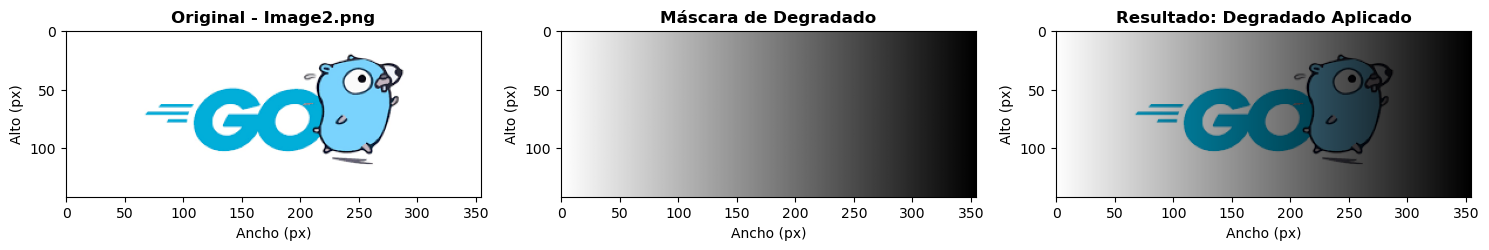

Imagen con degradado: (142, 355, 3)
Guardada como 'ej5_degradado_lineal.png'


In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Cargar imagen
imagen = cv2.imread('Image2.png')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
alto, ancho = imagen.shape[:2]

# Crear máscara de degradado horizontal
# Izquierda (claro, factor=1.0) -> Derecha (oscuro, factor=0.0)
gradiente = np.linspace(1.0, 0.0, ancho).reshape(1, ancho)
# Expandir a todas las filas
mascara = np.repeat(gradiente, alto, axis=0)
# Expandir a 3 canales
mascara_3ch = np.stack([mascara] * 3, axis=2)

# Aplicar degradado multiplicativo
resultado = (imagen_rgb.astype(np.float64) * mascara_3ch).astype(np.uint8)

# Guardar resultado
cv2.imwrite('ej5_degradado_lineal.png', cv2.cvtColor(resultado, cv2.COLOR_RGB2BGR))

# Mostrar comparación
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(imagen_rgb)
axes[0].set_title('Original - Image2.png', fontweight='bold')

axes[1].imshow(mascara, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Máscara de Degradado', fontweight='bold')

axes[2].imshow(resultado)
axes[2].set_title('Resultado: Degradado Aplicado', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Ancho (px)')
    ax.set_ylabel('Alto (px)')

plt.tight_layout()
plt.show()

print(f"Imagen con degradado: {resultado.shape}")
print("Guardada como 'ej5_degradado_lineal.png'")

### Ejercicio - 6
Elabora una **imagen original** usando únicamente cuadrados de colores, posterior a ello se aplica el **filtro Bayer** en todas sus combinaciones:
- **RGGB** (BG2BGR)
- **BGGR** (RG2BGR)
- **GRBG** (GB2BGR)
- **GBRG** (GR2BGR)

Mostrar y guardar todos los resultados con sus títulos correspondientes.

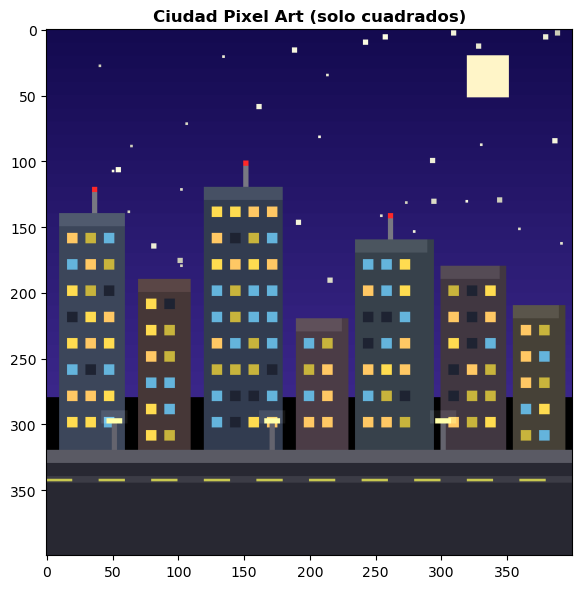

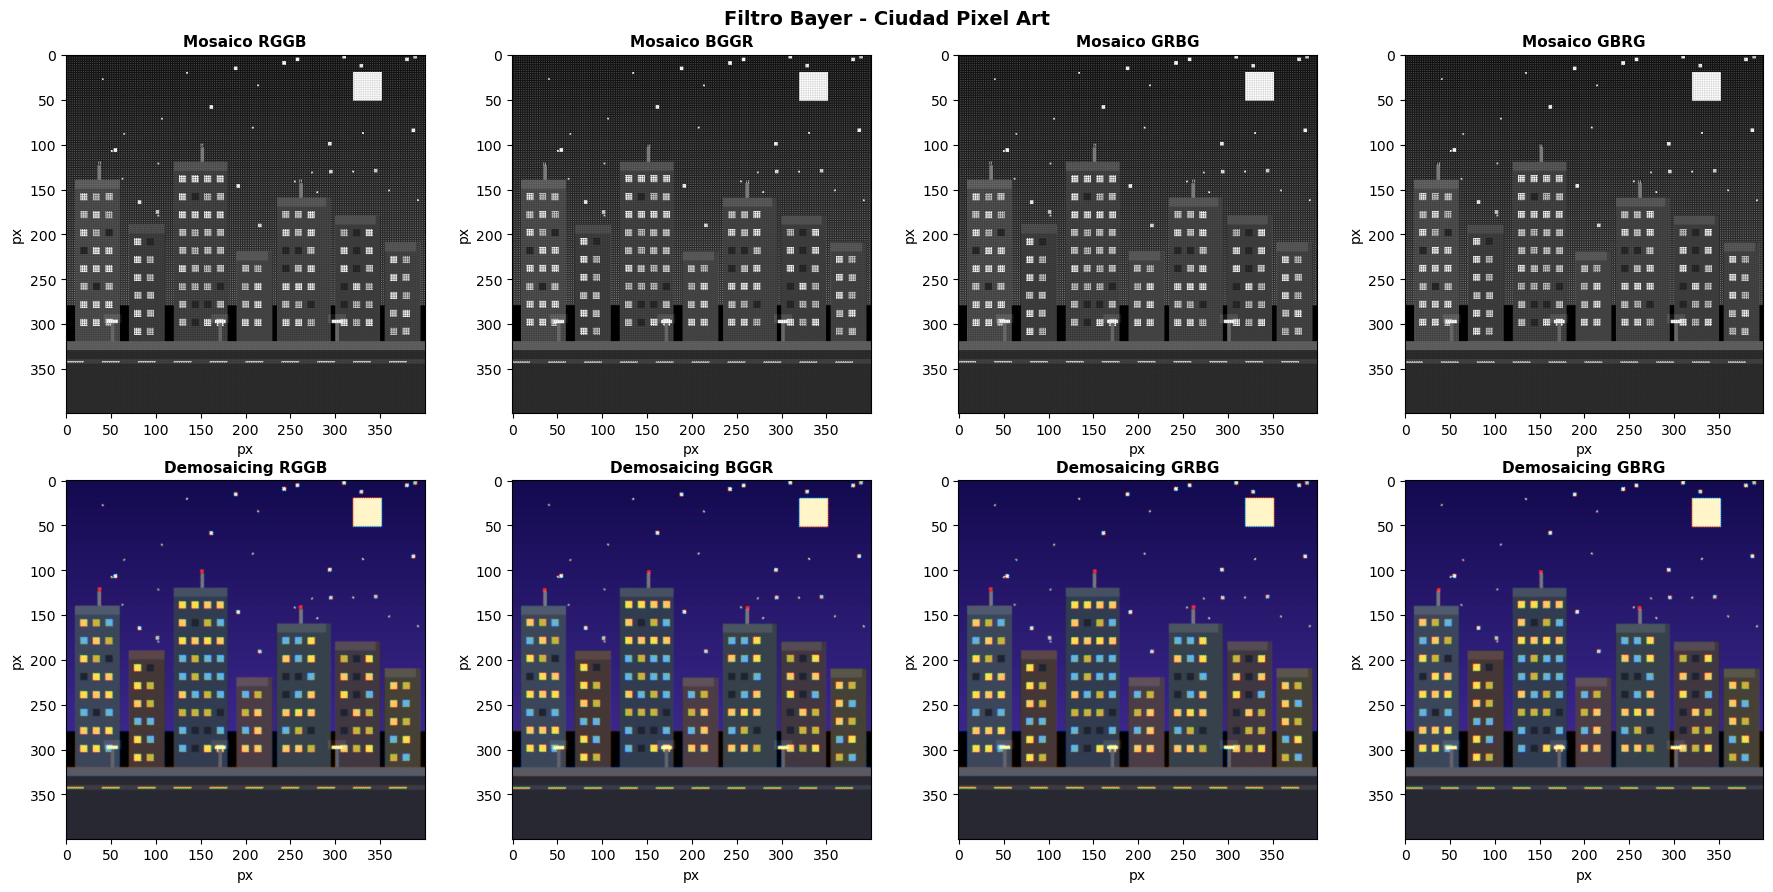

Imágenes guardadas: ciudad original + 4 mosaicos + 4 reconstrucciones


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ========== CREAR CIUDAD PIXEL ART CON CUADRADOS ==========
tam = 400
ciudad = np.zeros((tam, tam, 3), dtype=np.uint8)

# --- Cielo degradado (cuadrados de 10px) ---
for y in range(0, 280, 10):
    t = y / 280
    r = int(20 + t * 40)
    g = int(10 + t * 30)
    b = int(80 + t * 60)
    ciudad[y:y+10, :] = [r, g, b]

# --- Estrellas (cuadrados 4x4 y 2x2) ---
np.random.seed(42)
for _ in range(40):
    sx = np.random.randint(0, tam - 4)
    sy = np.random.randint(0, 200)
    s = np.random.choice([2, 4])
    brillo = np.random.randint(200, 256)
    ciudad[sy:sy+s, sx:sx+s] = [brillo, brillo, int(brillo * 0.9)]

# --- Luna (cuadrados 8x8 formando un bloque) ---
for dy in range(0, 32, 8):
    for dx in range(0, 32, 8):
        ciudad[20+dy:28+dy, 320+dx:328+dx] = [255, 245, 200]

# --- Suelo ---
ciudad[320:, :] = [40, 40, 50]
# Acera
ciudad[320:330, :] = [90, 90, 100]

# --- Edificios ---
edificios = [
    # (x, ancho, alto, color_paredes, color_techo)
    (10,  50, 180, (60, 70, 90),   (80, 90, 110)),
    (70,  40, 130, (70, 55, 55),   (90, 70, 70)),
    (120, 60, 200, (50, 60, 80),   (70, 80, 100)),
    (190, 35, 100, (75, 60, 70),   (95, 80, 90)),
    (235, 55, 160, (55, 65, 75),   (75, 85, 95)),
    (300, 45, 140, (65, 55, 65),   (85, 75, 85)),
    (355, 35, 110, (70, 65, 55),   (90, 85, 75)),
]

for ex, ew, eh, color_p, color_t in edificios:
    y_top = 320 - eh
    # Cuerpo del edificio (cuadrados de 10px)
    for by in range(y_top, 320, 10):
        for bx in range(ex, min(ex + ew, tam), 10):
            ciudad[by:by+10, bx:bx+10] = color_p
    # Techo (franja de 10px)
    ciudad[y_top:y_top+10, ex:ex+ew] = color_t

# --- Ventanas (cuadrados 8x8, con separación de 12px) ---
colores_ventana = [
    (255, 220, 80),   # Amarillo cálido (encendida)
    (200, 180, 60),   # Amarillo tenue
    (30, 35, 50),     # Apagada (oscura)
    (100, 180, 220),  # Azul TV
    (255, 200, 100),  # Naranja cálido
]

np.random.seed(7)
for ex, ew, eh, _, _ in edificios:
    y_top = 320 - eh
    for wy in range(y_top + 15, 310, 20):
        for wx in range(ex + 6, ex + ew - 8, 14):
            color_v = colores_ventana[np.random.randint(0, len(colores_ventana))]
            ciudad[wy:wy+8, wx:wx+8] = color_v

# --- Antenas en algunos edificios (cuadrados 4x4 apilados) ---
antenas = [(35, 320 - 180), (150, 320 - 200), (260, 320 - 160)]
for ax, ay in antenas:
    for i in range(4):
        ciudad[ay - 4*i - 4:ay - 4*i, ax:ax+4] = [120, 120, 130]
    # Luz roja en la punta
    ciudad[ay - 16 - 4:ay - 16, ax:ax+4] = [255, 40, 40]

# --- Farolas en la acera (cuadrados) ---
for fx in [50, 170, 300]:
    # Poste
    ciudad[300:320, fx:fx+4] = [100, 100, 110]
    # Luz
    ciudad[296:300, fx-4:fx+8] = [255, 240, 150]
    # Resplandor (cuadrado semitransparente simulado)
    for gy in range(290, 300):
        for gx in range(fx-8, fx+12):
            if 0 <= gx < tam:
                orig = ciudad[gy, gx].astype(np.float64)
                ciudad[gy, gx] = np.clip(orig + 20, 0, 255).astype(np.uint8)

# --- Calle con líneas ---
ciudad[340:345, :] = [60, 60, 70]
for lx in range(0, tam, 40):
    ciudad[342:344, lx:lx+20] = [200, 200, 80]

# Guardar imagen original
ciudad_bgr = cv2.cvtColor(ciudad, cv2.COLOR_RGB2BGR)
cv2.imwrite('ej6_ciudad_pixelart.png', ciudad_bgr)

plt.figure(figsize=(6, 6))
plt.imshow(ciudad)
plt.title('Ciudad Pixel Art (solo cuadrados)', fontweight='bold', fontsize=12)
plt.axis('on')
plt.tight_layout()
plt.show()

# ========== APLICAR FILTRO BAYER EN TODAS SUS COMBINACIONES ==========
def aplicar_bayer(img_rgb, patron):
    """Simula el mosaico Bayer sobre una imagen RGB"""
    alto, ancho = img_rgb.shape[:2]
    R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]
    bayer = np.zeros((alto, ancho), dtype=np.uint8)
    y_par, y_impar = np.arange(0, alto, 2), np.arange(1, alto, 2)
    x_par, x_impar = np.arange(0, ancho, 2), np.arange(1, ancho, 2)
    
    canales = {
        'RGGB': (R, G, G, B),
        'BGGR': (B, G, G, R),
        'GRBG': (G, R, B, G),
        'GBRG': (G, B, R, G),
    }
    tl, tr, bl, br = canales[patron]
    bayer[np.ix_(y_par, x_par)]     = tl[np.ix_(y_par, x_par)]
    bayer[np.ix_(y_par, x_impar)]   = tr[np.ix_(y_par, x_impar)]
    bayer[np.ix_(y_impar, x_par)]   = bl[np.ix_(y_impar, x_par)]
    bayer[np.ix_(y_impar, x_impar)] = br[np.ix_(y_impar, x_impar)]
    return bayer

bayer_configs = [
    ('RGGB', cv2.COLOR_BAYER_BG2BGR),
    ('BGGR', cv2.COLOR_BAYER_RG2BGR),
    ('GRBG', cv2.COLOR_BAYER_GB2BGR),
    ('GBRG', cv2.COLOR_BAYER_GR2BGR),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, (patron, demosaic_code) in enumerate(bayer_configs):
    bayer_img = aplicar_bayer(ciudad, patron)
    reconstruida = cv2.cvtColor(bayer_img, demosaic_code)
    reconstruida_rgb = cv2.cvtColor(reconstruida, cv2.COLOR_BGR2RGB)
    
    cv2.imwrite(f'ej6_bayer_{patron}_mosaico.png', bayer_img)
    cv2.imwrite(f'ej6_bayer_{patron}_reconstruida.png', reconstruida)
    
    axes[0, i].imshow(bayer_img, cmap='gray')
    axes[0, i].set_title(f'Mosaico {patron}', fontweight='bold', fontsize=11)
    axes[1, i].imshow(reconstruida_rgb)
    axes[1, i].set_title(f'Demosaicing {patron}', fontweight='bold', fontsize=11)

for ax in axes.flatten():
    ax.set_xlabel('px')
    ax.set_ylabel('px')

fig.suptitle('Filtro Bayer - Ciudad Pixel Art', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Imágenes guardadas: ciudad original + {len(bayer_configs)} mosaicos + {len(bayer_configs)} reconstrucciones")